In [1]:
# ============================================================
# Brain Tumor MRI Classification using Transfer Learning
# Cell 1 - Import Libraries & Environment Setup
# ============================================================

import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Random Seed (Reproducibility)
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ------------------------------------------------------------
# Display Versions
# ------------------------------------------------------------

print("="*60)
print("TensorFlow Version :", tf.__version__)
print("Keras Version      :", keras.__version__)
print("NumPy Version      :", np.__version__)
print("Pandas Version     :", pd.__version__)
print("="*60)

TensorFlow Version : 2.20.0
Keras Version      : 3.13.2
NumPy Version      : 2.0.2
Pandas Version     : 2.3.3


In [2]:
# ============================================================
# Cell 2 - GPU Setup & Mixed Precision
# ============================================================

from tensorflow.keras import mixed_precision

# Detect available GPUs
gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)

if gpus:
    print(f"✅ GPU Detected: {len(gpus)}")
    
    for i, gpu in enumerate(gpus):
        print(f"GPU {i+1}: {gpu.name}")
        
        # Enable memory growth
        tf.config.experimental.set_memory_growth(gpu, True)

    # Enable mixed precision
    mixed_precision.set_global_policy('mixed_float16')

    print("\nMixed Precision Policy:",
          mixed_precision.global_policy())

else:
    print("❌ No GPU detected. Training will use CPU.")

print("=" * 60)

# TensorFlow build information
print("TensorFlow Built with CUDA :", tf.test.is_built_with_cuda())
print("GPU Available              :", tf.config.list_physical_devices('GPU'))

✅ GPU Detected: 2
GPU 1: /physical_device:GPU:0
GPU 2: /physical_device:GPU:1

Mixed Precision Policy: <DTypePolicy "mixed_float16">
TensorFlow Built with CUDA : True
GPU Available              : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ============================================================
# Cell 3 - Dataset Paths & Class Information
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Dataset Paths
# ------------------------------------------------------------

DATASET_PATH = "/kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset"

train_dir = os.path.join(DATASET_PATH, "Training")
test_dir = os.path.join(DATASET_PATH, "Testing")

print("=" * 60)
print("Training Directory :", train_dir)
print("Testing Directory  :", test_dir)
print("=" * 60)

# ------------------------------------------------------------
# Verify Dataset
# ------------------------------------------------------------

assert os.path.exists(train_dir), f"Training folder not found: {train_dir}"
assert os.path.exists(test_dir), f"Testing folder not found: {test_dir}"

# ------------------------------------------------------------
# Read Class Names
# ------------------------------------------------------------

class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("\nClasses Found:")
for idx, cls in enumerate(class_names):
    print(f"{idx}: {cls}")

# ------------------------------------------------------------
# Count Images
# ------------------------------------------------------------

train_counts = {}
test_counts = {}

for cls in class_names:
    train_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))
    test_counts[cls] = len(os.listdir(os.path.join(test_dir, cls)))

summary = pd.DataFrame({
    "Training": train_counts,
    "Testing": test_counts
})

summary["Total"] = summary["Training"] + summary["Testing"]

print("\nDataset Summary")
display(summary)

print("\nTotal Training Images :", summary["Training"].sum())
print("Total Testing Images  :", summary["Testing"].sum())
print("Grand Total Images    :", summary["Total"].sum())

Training Directory : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Training
Testing Directory  : /kaggle/input/datasets/masoudnickparvar/brain-tumor-mri-dataset/Testing

Classes Found:
0: glioma
1: meningioma
2: notumor
3: pituitary

Dataset Summary


,Training,Testing,Total
glioma,1400,400,1800
meningioma,1400,400,1800
notumor,1400,400,1800
pituitary,1400,400,1800



Total Training Images : 5600
Total Testing Images  : 1600
Grand Total Images    : 7200


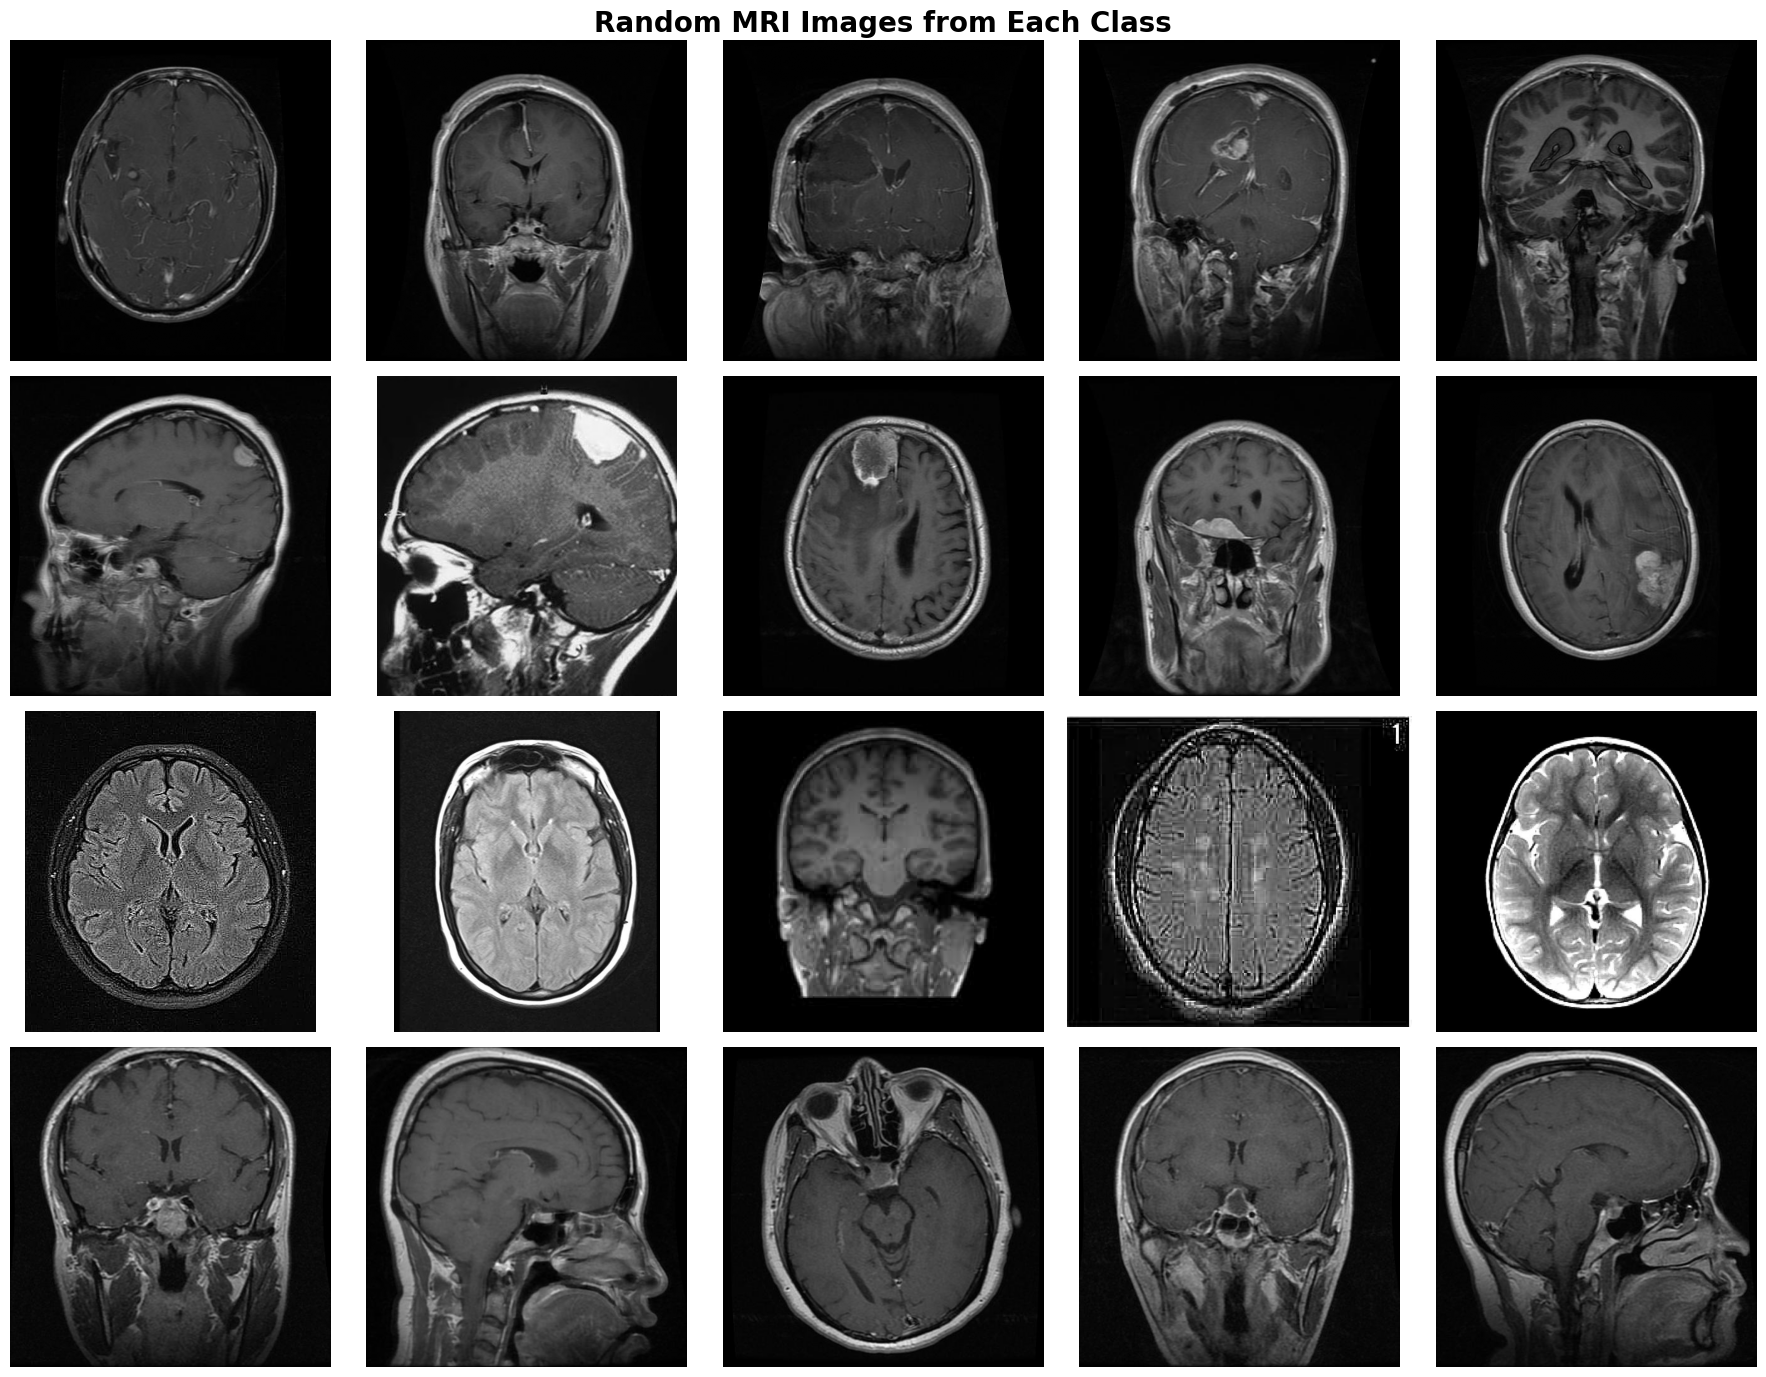

In [4]:
# ============================================================
# Cell 4 - Visualize Random MRI Images
# ============================================================

import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# ------------------------------------------------------------
# Display random images from each class
# ------------------------------------------------------------

samples_per_class = 5

fig, axes = plt.subplots(
    len(class_names),
    samples_per_class,
    figsize=(18, 14)
)

for row, class_name in enumerate(class_names):

    class_path = os.path.join(train_dir, class_name)

    image_files = random.sample(
        os.listdir(class_path),
        samples_per_class
    )

    for col, image_name in enumerate(image_files):

        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].axis("off")

        if col == 0:
            axes[row, col].set_ylabel(
                class_name,
                fontsize=14,
                fontweight="bold"
            )

plt.suptitle(
    "Random MRI Images from Each Class",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Cell 5 - Analyze Image Dimensions
# ============================================================

from PIL import Image
from collections import Counter
from tqdm import tqdm
import os

# ------------------------------------------------------------
# Analyze image dimensions
# ------------------------------------------------------------

image_sizes = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for image_name in tqdm(os.listdir(class_path), desc=f"{class_name}"):

        image_path = os.path.join(class_path, image_name)

        try:
            img = Image.open(image_path)
            image_sizes.append(img.size)   # (width, height)
        except:
            continue

# ------------------------------------------------------------
# Dataset Statistics
# ------------------------------------------------------------

widths = [size[0] for size in image_sizes]
heights = [size[1] for size in image_sizes]

print("=" * 60)
print(f"Total Images Analysed : {len(image_sizes)}")
print("=" * 60)

print(f"Minimum Width  : {min(widths)}")
print(f"Maximum Width  : {max(widths)}")

print(f"Minimum Height : {min(heights)}")
print(f"Maximum Height : {max(heights)}")

# ------------------------------------------------------------
# Most Common Image Sizes
# ------------------------------------------------------------

size_counter = Counter(image_sizes)

print("\nMost Common Image Sizes:\n")

for size, count in size_counter.most_common(10):
    print(f"{size}  --->  {count} images")

pituitary: 100%|██████████| 1400/1400 [00:08<00:00, 161.05it/s]

Total Images Analysed : 5600
Minimum Width  : 150
Maximum Width  : 1375
Minimum Height : 168
Maximum Height : 1446

Most Common Image Sizes:

(512, 512)  --->  4012 images
(225, 225)  --->  253 images
(630, 630)  --->  69 images
(201, 251)  --->  40 images
(236, 236)  --->  39 images
(442, 442)  --->  38 images
(150, 198)  --->  33 images
(232, 217)  --->  32 images
(228, 221)  --->  32 images
(428, 417)  --->  31 images


In [6]:
# ============================================================
# Cell 6 - Create TensorFlow Datasets
# ============================================================

import tensorflow as tf

# Configuration
IMAGE_SIZE = (300, 300)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Class names (from Cell 3)
class_names = [
    "glioma",
    "meningioma",
    "notumor",
    "pituitary"
]

# -------------------- Training Dataset --------------------

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.20,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

# -------------------- Validation Dataset --------------------

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.20,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# -------------------- Test Dataset --------------------

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

# -------------------- Performance --------------------

train_dataset = train_dataset.cache().prefetch(AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(AUTOTUNE)

# -------------------- Information --------------------

print("=" * 60)
print("Classes:", class_names)
print("=" * 60)

print(f"Training Batches  : {tf.data.experimental.cardinality(train_dataset).numpy()}")
print(f"Validation Batches: {tf.data.experimental.cardinality(validation_dataset).numpy()}")
print(f"Testing Batches   : {tf.data.experimental.cardinality(test_dataset).numpy()}")

for images, labels in train_dataset.take(1):
    print("\nImage Batch Shape :", images.shape)
    print("Label Batch Shape :", labels.shape)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


I0000 00:00:1784890614.787117      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1784890614.790156      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training Batches  : 140
Validation Batches: 35
Testing Batches   : 50

Image Batch Shape : (32, 300, 300, 3)
Label Batch Shape : (32, 4)


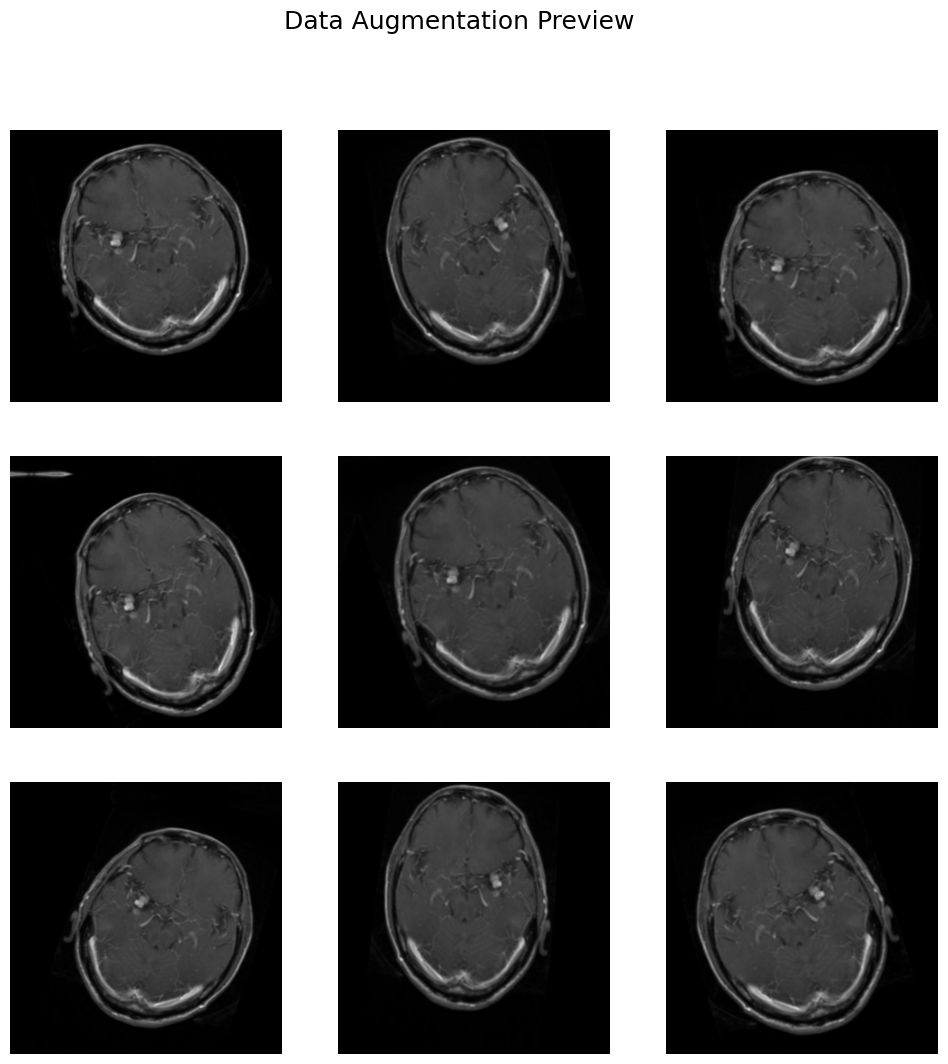

In [7]:
# ============================================================
# Cell 7 - Data Augmentation
# ============================================================

from tensorflow.keras import layers

# ------------------------------------------------------------
# Data Augmentation Pipeline
# ------------------------------------------------------------

data_augmentation = tf.keras.Sequential([
    
    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.12),

    layers.RandomZoom(
        height_factor=0.10,
        width_factor=0.10
    ),

    layers.RandomTranslation(
        height_factor=0.08,
        width_factor=0.08
    ),

    layers.RandomContrast(0.15),

], name="Data_Augmentation")

# ------------------------------------------------------------
# Visualize Augmented Images
# ------------------------------------------------------------

plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):

    first_image = images[0]

    for i in range(9):

        ax = plt.subplot(3, 3, i + 1)

        augmented = data_augmentation(
            tf.expand_dims(first_image, axis=0),
            training=True
        )

        plt.imshow(augmented[0].numpy().astype("uint8"))
        plt.axis("off")

plt.suptitle("Data Augmentation Preview", fontsize=18)
plt.show()

In [8]:
# ============================================================
# Cell 8 - Build EfficientNetV2B3 Transfer Learning Model
# ============================================================

from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input
from tensorflow.keras import layers, Model

# ------------------------------------------------------------
# Input Layer
# ------------------------------------------------------------

inputs = layers.Input(shape=(300, 300, 3), name="input_image")

# ------------------------------------------------------------
# Data Augmentation
# ------------------------------------------------------------

x = data_augmentation(inputs)

# ------------------------------------------------------------
# EfficientNetV2 Preprocessing
# ------------------------------------------------------------

x = preprocess_input(x)

# ------------------------------------------------------------
# Load Pretrained EfficientNetV2B3
# ------------------------------------------------------------

base_model = EfficientNetV2B3(
    include_top=False,
    weights="imagenet",
    input_shape=(300, 300, 3)
)

# Freeze pretrained weights
base_model.trainable = False

# Forward pass
x = base_model(x, training=False)

# ------------------------------------------------------------
# Classification Head
# ------------------------------------------------------------

x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.40)(x)

x = layers.Dense(
    512,
    activation="relu",
    kernel_initializer="he_normal"
)(x)

x = layers.BatchNormalization()(x)

x = layers.Dropout(0.30)(x)

outputs = layers.Dense(
    4,
    activation="softmax",
    dtype="float32",
    name="prediction"
)(x)

# ------------------------------------------------------------
# Final Model
# ------------------------------------------------------------

model = Model(inputs, outputs, name="BrainTumor_EfficientNetV2B3")

# ------------------------------------------------------------
# Model Summary
# ------------------------------------------------------------

model.summary()

print("\nTotal Parameters :", model.count_params())
print("Trainable Parameters :", sum(
    tf.keras.backend.count_params(w) for w in model.trainable_weights
))
print("Non-Trainable Parameters :", sum(
    tf.keras.backend.count_params(w) for w in model.non_trainable_weights
))

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "BrainTumor_EfficientNetV2B3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Data_Augmentation (Sequential)  │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,727,810 (52.37 MB)

 Trainable params: 793,092 (3.03 MB)

 Non-trainable params: 12,934,718 (49.34 MB)


Total Parameters : 13727810
Trainable Parameters : 793092
Non-Trainable Parameters : 12934718


In [9]:
# ============================================================
# Cell 9 - Compile Model & Training Configuration
# ============================================================

import tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
    CSVLogger
)

# ------------------------------------------------------------
# Training Configuration
# ------------------------------------------------------------

EPOCHS = 20
INITIAL_LR = 1e-3
WEIGHT_DECAY = 1e-4

# ------------------------------------------------------------
# Learning Rate Schedule
# ------------------------------------------------------------

lr_schedule = CosineDecay(
    initial_learning_rate=INITIAL_LR,
    decay_steps=EPOCHS * tf.data.experimental.cardinality(train_dataset).numpy(),
    alpha=1e-6
)

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Loss Function
# ------------------------------------------------------------

loss_function = CategoricalCrossentropy(
    label_smoothing=0.1
)

# ------------------------------------------------------------
# Compile Model
# ------------------------------------------------------------

model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

callbacks = [

    ModelCheckpoint(
        filepath="best_brain_tumor_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    CSVLogger(
        "training_log.csv",
        append=False
    )

]

# ------------------------------------------------------------
# Display Configuration
# ------------------------------------------------------------

print("=" * 60)
print("Training Configuration")
print("=" * 60)

print(f"Epochs            : {EPOCHS}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Initial LR        : {INITIAL_LR}")
print(f"Weight Decay      : {WEIGHT_DECAY}")
print(f"Loss Function     : Categorical Crossentropy")
print(f"Label Smoothing   : 0.1")
print(f"Optimizer         : AdamW")
print(f"Learning Schedule : Cosine Decay")

print("=" * 60)

Training Configuration
Epochs            : 20
Batch Size        : 32
Initial LR        : 0.001
Weight Decay      : 0.0001
Loss Function     : Categorical Crossentropy
Label Smoothing   : 0.1
Optimizer         : AdamW
Learning Schedule : Cosine Decay


In [10]:
# ============================================================
# Cell 10 - Train Classification Head
# ============================================================

print("=" * 60)
print("Stage 1 Training")
print("Training only the classification head...")
print("=" * 60)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nStage 1 Training Completed Successfully!")

Stage 1 Training
Training only the classification head...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.6878 - loss: 1.2053 - precision: 0.7160 - recall: 0.6630
Epoch 1: val_accuracy improved from None to 0.92411, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 249ms/step - accuracy: 0.7348 - loss: 1.0555 - precision: 0.7618 - recall: 0.7051 - val_accuracy: 0.9241 - val_loss: 0.5649 - val_precision: 0.9710 - val_recall: 0.8661
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.7876 - loss: 0.8221 - precision: 0.8191 - recall: 0.7522
Epoch 2: val_accuracy improved from 0.92411 to 0.94643, saving model to best_brain_tumor_model.keras

Epoch 2: finished saving model to best_brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 25s 177ms/step - accuracy: 0.8031 - loss: 0.7916 - precision: 0.8312 - recall: 0.7661 - val_accuracy: 0.9464 - val_loss: 0.5216 - val_

In [11]:
# ============================================================
# Cell 11 - Fine-Tuning EfficientNetV2B3
# ============================================================

print("=" * 60)
print("Stage 2 - Fine Tuning")
print("=" * 60)

# ------------------------------------------------------------
# Unfreeze the base model
# ------------------------------------------------------------

base_model.trainable = True

# Freeze approximately the first 70% of layers
fine_tune_at = int(len(base_model.layers) * 0.70)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# ------------------------------------------------------------
# Fine-Tuning Optimizer
# ------------------------------------------------------------

FINE_TUNE_EPOCHS = 10
FINE_TUNE_LR = 1e-5

optimizer = AdamW(
    learning_rate=FINE_TUNE_LR,
    weight_decay=1e-5
)

# ------------------------------------------------------------
# Recompile Model
# ------------------------------------------------------------

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(
        label_smoothing=0.1
    ),
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

print("\nTrainable Layers:",
      sum(layer.trainable for layer in model.layers))

print("Fine-Tuning Learning Rate:", FINE_TUNE_LR)

Stage 2 - Fine Tuning

Trainable Layers: 10
Fine-Tuning Learning Rate: 1e-05


In [12]:
# ============================================================
# Cell 12 - Fine-Tune Training
# ============================================================

history_finetune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nFine-Tuning Completed Successfully!")

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9043 - loss: 0.5701 - precision: 0.9294 - recall: 0.8676
Epoch 1: val_accuracy improved from 0.98661 to 0.98750, saving model to best_brain_tumor_model.keras

Epoch 1: finished saving model to best_brain_tumor_model.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 67s 263ms/step - accuracy: 0.9049 - loss: 0.5710 - precision: 0.9287 - recall: 0.8665 - val_accuracy: 0.9875 - val_loss: 0.4181 - val_precision: 0.9919 - val_recall: 0.9830
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9063 - loss: 0.5646 - precision: 0.9319 - recall: 0.8735
Epoch 2: val_accuracy did not improve from 0.98750
140/140 ━━━━━━━━━━━━━━━━━━━━ 30s 216ms/step - accuracy: 0.9085 - loss: 0.5640 - precision: 0.9299 - recall: 0.8799 - val_accuracy: 0.9830 - val_loss: 0.4250 - val_precision: 0.9900 - val_recall: 0.9750
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.9170 - loss: 0.5534 - precision: 0.9388 - recall: 0.8823
Epoch

In [13]:
# ============================================================
# Cell 13 - Evaluate on Test Dataset
# ============================================================

print("=" * 60)
print("Evaluating Model on Test Dataset")
print("=" * 60)

test_loss, test_accuracy, test_precision, test_recall = model.evaluate(
    test_dataset,
    verbose=1
)

print("\n" + "=" * 60)
print("Test Results")
print("=" * 60)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy*100:.2f}%")
print(f"Test Precision : {test_precision:.4f}")
print(f"Test Recall    : {test_recall:.4f}")
print("=" * 60)

Evaluating Model on Test Dataset
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.8900 - loss: 0.5913 - precision: 0.9161 - recall: 0.8600

Test Results
Test Loss      : 0.5913
Test Accuracy  : 89.00%
Test Precision : 0.9161
Test Recall    : 0.8600


50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step
Classification Report
              precision    recall  f1-score   support

      glioma     0.9290    0.7850    0.8509       400
  meningioma     0.8478    0.8075    0.8271       400
     notumor     0.9159    0.9800    0.9469       400
   pituitary     0.8720    0.9875    0.9261       400

    accuracy                         0.8900      1600
   macro avg     0.8912    0.8900    0.8878      1600
weighted avg     0.8912    0.8900    0.8878      1600



<Figure size 800x800 with 0 Axes>

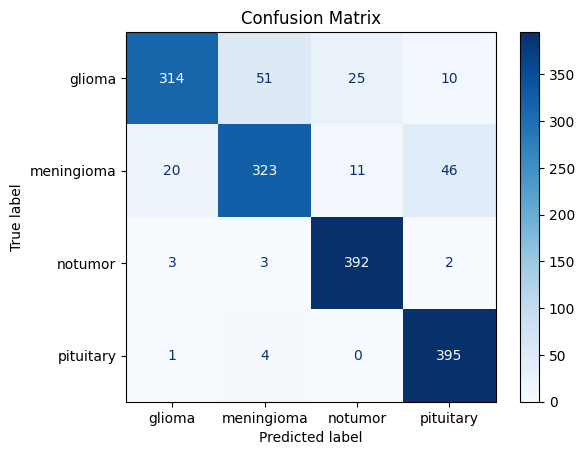

In [14]:
# ============================================================
# Cell 14 - Predictions & Confusion Matrix
# ============================================================

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

y_true = np.concatenate(
    [labels.numpy() for _, labels in test_dataset]
)

y_true = np.argmax(y_true, axis=1)

predictions = model.predict(test_dataset, verbose=1)

y_pred = np.argmax(predictions, axis=1)

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("=" * 60)
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

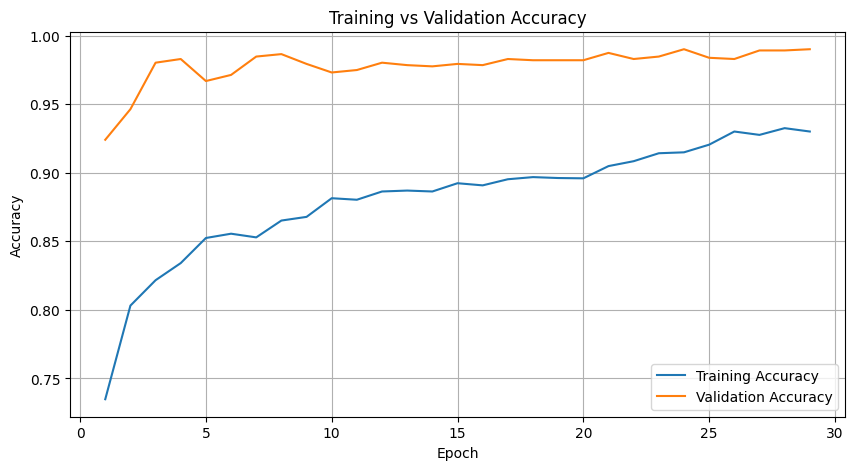

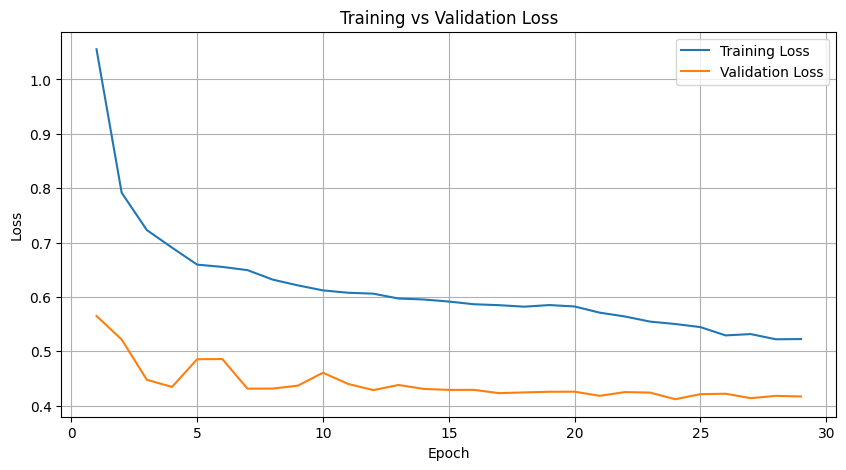

In [15]:
# ============================================================
# Cell 15 - Training Curves
# ============================================================

import matplotlib.pyplot as plt

history_dict = history.history
fine_dict = history_finetune.history

train_acc = history_dict["accuracy"] + fine_dict["accuracy"]
val_acc = history_dict["val_accuracy"] + fine_dict["val_accuracy"]

train_loss = history_dict["loss"] + fine_dict["loss"]
val_loss = history_dict["val_loss"] + fine_dict["val_loss"]

epochs = range(1, len(train_acc) + 1)

# ---------------- Accuracy ----------------

plt.figure(figsize=(10,5))

plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

# ---------------- Loss ----------------

plt.figure(figsize=(10,5))

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

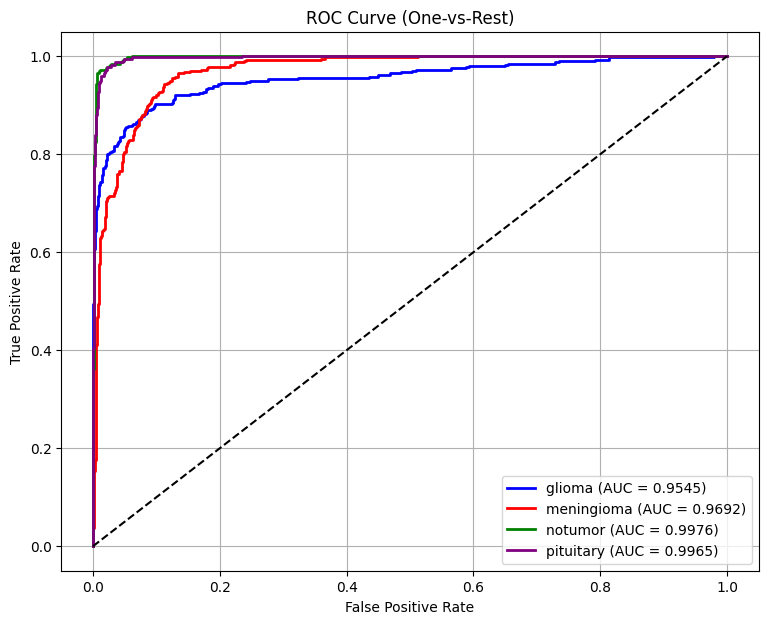

In [16]:
# ============================================================
# Cell 16 - ROC Curve
# ============================================================

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# One-hot encode labels
y_true_bin = label_binarize(y_true, classes=[0,1,2,3])

plt.figure(figsize=(9,7))

colors = ["blue","red","green","purple"]

for i in range(4):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        predictions[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        color=colors[i],
        label=f"{class_names[i]} (AUC = {roc_auc:.4f})"
    )

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)

plt.show()

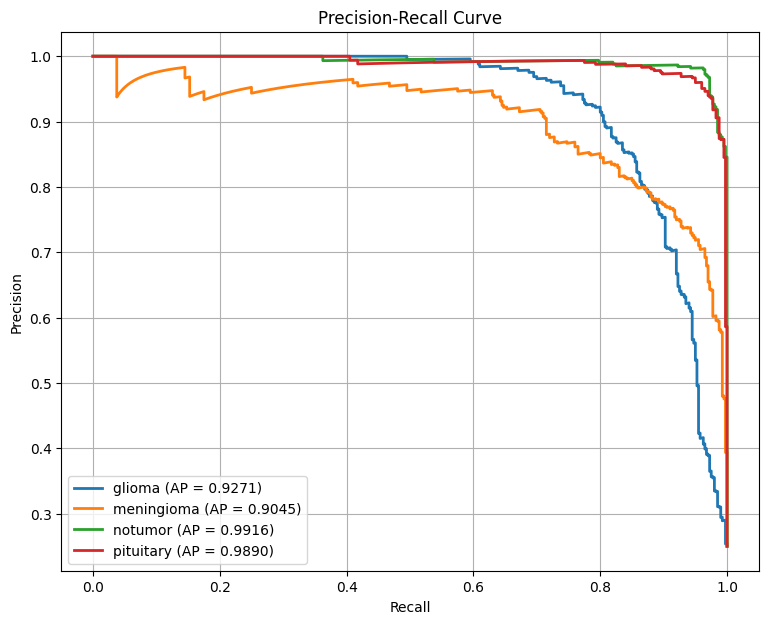

In [17]:
# ============================================================
# Cell 17 - Precision Recall Curves
# ============================================================

from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

plt.figure(figsize=(9,7))

for i in range(4):

    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        predictions[:, i]
    )

    ap = average_precision_score(
        y_true_bin[:, i],
        predictions[:, i]
    )

    plt.plot(
        recall,
        precision,
        lw=2,
        label=f"{class_names[i]} (AP = {ap:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.grid(True)

plt.show()

In [18]:
# ============================================================
# Cell 18 - Save Final Model
# ============================================================

import json

# Save model
model.save("BrainTumor_EfficientNetV2B3.keras")

# Save H5 version
model.save("BrainTumor_EfficientNetV2B3.h5")

# Save class labels
with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Model Saved Successfully!")

print("\nGenerated Files")

print("✔ BrainTumor_EfficientNetV2B3.keras")
print("✔ BrainTumor_EfficientNetV2B3.h5")
print("✔ class_names.json")

Model Saved Successfully!

Generated Files
✔ BrainTumor_EfficientNetV2B3.keras
✔ BrainTumor_EfficientNetV2B3.h5
✔ class_names.json


In [19]:
import os
import zipfile

files_to_zip = [
    "BrainTumor_EfficientNetV2B3.keras",
    "BrainTumor_EfficientNetV2B3.h5",
    "class_names.json",
    "training_log.csv",
    "best_brain_tumor_model.keras"
]

zip_filename = "BrainTumor_TransferLearning_Project.zip"

with zipfile.ZipFile(zip_filename, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)
            print(f"Added: {file}")
        else:
            print(f"Missing: {file}")

print(f"\nZIP file created: {zip_filename}")

Added: BrainTumor_EfficientNetV2B3.keras
Added: BrainTumor_EfficientNetV2B3.h5
Added: class_names.json
Added: training_log.csv
Added: best_brain_tumor_model.keras

ZIP file created: BrainTumor_TransferLearning_Project.zip
